In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
modelo = joblib.load('../modelo_adaboost.pkl')

colunas_X = ['LapNumber', 'Stint', 'TyreLife', 'Compound_INTERMEDIATE']

dados_simulados = {
    'LapNumber' : list(range(1, 31)),
    'Stint' : [1.0] * 30,
    'TyreLife' : list(range(1, 31)),
    'Compound_INTERMEDIATE' : [1] * 30
}

df_simulacaoPista = pd.DataFrame(dados_simulados)
df_simulacaoPista = df_simulacaoPista[colunas_X]  # Reordena as colunas para corresponder ao conjunto de treinamento
tempos_simulados = modelo.predict(df_simulacaoPista)
df_simulacaoPista.head()

,LapNumber,Stint,TyreLife,Compound_INTERMEDIATE
0,1,1.0,1,1
1,2,1.0,2,1
2,3,1.0,3,1
3,4,1.0,4,1
4,5,1.0,5,1


,LapNumber,Stint,TyreLife,Compound_INTERMEDIATE,Tempo_Previsto
0,1,1.0,1,1,86.394000
1,2,1.0,2,1,86.394000
2,3,1.0,3,1,86.394000
3,4,1.0,4,1,86.471000
4,5,1.0,5,1,84.634857


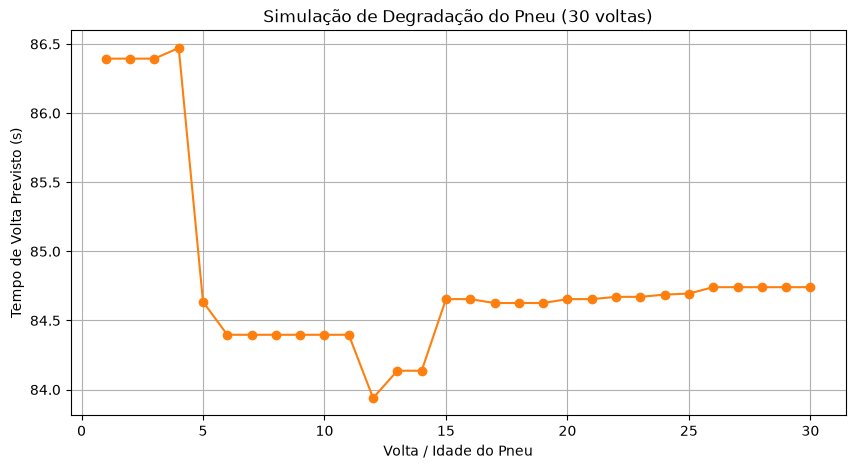

In [3]:
df_simulacaoPista['Tempo_Previsto'] = tempos_simulados

display(df_simulacaoPista.head())

plt.figure(figsize=(10, 5))
plt.plot(df_simulacaoPista['LapNumber'], df_simulacaoPista['Tempo_Previsto'], marker='o', color='#ff7f0e')
plt.title('Simulação de Degradação do Pneu (30 voltas)')
plt.xlabel('Volta / Idade do Pneu')
plt.ylabel('Tempo de Volta Previsto (s)')
plt.grid(True)
plt.show()

In [4]:
df_simulacaoPista['Delta_Tempo'] = df_simulacaoPista['Tempo_Previsto'].diff().fillna(0) #aqui calculamos a variacao de tempo de volta em volta

linha_cliff = df_simulacaoPista.loc[df_simulacaoPista['Delta_Tempo'].idxmax()]  # Encontra a linha com o maior delta de tempo

volta_cliff = int(linha_cliff['LapNumber'])
perda_tempo = linha_cliff['Delta_Tempo']

print("=" * 45)
print("      RELATÓRIO DE ESTRATÉGIA DE CORRIDA      ")
print("=" * 45)
print(f"• Ponto de 'Cliff' detectado: Volta {volta_cliff}")
print(f"• Perda de ritmo estimada: +{perda_tempo:.3f}s")
print(f"• JANELA IDEAL DE PIT STOP: Voltas {volta_cliff - 1} a {volta_cliff}")
print("=" * 45)

      RELATÓRIO DE ESTRATÉGIA DE CORRIDA      
• Ponto de 'Cliff' detectado: Volta 15
• Perda de ritmo estimada: +0.518s
• JANELA IDEAL DE PIT STOP: Voltas 14 a 15
